# ⚙️ Feature Engineering — Used Car Price Prediction & Valuation System

**Objective:** Create new **business-driven features** from the preprocessed dataset that capture domain knowledge about the used car market and improve model predictive power.

**Target Variable:** `listed_price`

---

### Why Feature Engineering Matters

Raw features only capture what's directly measured. Feature engineering **encodes domain knowledge** into the data — for example, *"kilometres driven per year"* is a much better indicator of car usage than raw km alone, because a 10-year-old car with 50,000 km is very different from a 2-year-old car with 50,000 km.

### Roadmap

| Step | Task |
|------|------|
| 1 | Setup & Load Data |
| 2 | Create Ratio & Interaction Features |
| 3 | Create Flag/Binary Features |
| 4 | Feature Summary & Statistics |
| 5 | Correlation Analysis with Target |
| 6 | Random Forest Feature Importance |
| 7 | Business Interpretation |
| 8 | Feature Retention Recommendations |
| 9 | Save Final Dataset |

---
## Step 1 — Setup & Load Data

In [1]:
# ── Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

COLORS = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6',
          '#1abc9c', '#e67e22', '#34495e', '#16a085', '#c0392b']

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# ── Load preprocessed dataset ──
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('Feature_Engineering.ipynb'))
CSV_PATH = os.path.join(NOTEBOOK_DIR, 'preprocessed_car_data.csv')

if not os.path.exists(CSV_PATH):
    CSV_PATH = r'd:\MLPs\Used Car Price Prediction & Valuation System\preprocessed_car_data.csv'

df = pd.read_csv(CSV_PATH)

print(f'✅ Preprocessed dataset loaded!')
print(f'   Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Memory : {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB')

✅ Preprocessed dataset loaded!
   Shape  : 37,750 rows × 74 columns
   Memory : 21.3 MB


In [3]:
# ── Load the raw dataset too (needed for brand names, since OEM was label-encoded) ──
RAW_CSV_PATH = os.path.join(NOTEBOOK_DIR, 'cars_data_clean.csv')

if not os.path.exists(RAW_CSV_PATH):
    RAW_CSV_PATH = r'd:\MLPs\Used Car Price Prediction & Valuation System\cars_data_clean.csv'

df_raw = pd.read_csv(RAW_CSV_PATH, usecols=['oem'])  # Only need the oem column

print(f'✅ Raw dataset loaded for brand mapping ({len(df_raw):,} rows)')

✅ Raw dataset loaded for brand mapping (37,813 rows)


In [4]:
# Quick look at existing columns
print(f'\n📋 Current Columns ({len(df.columns)}):')
print('-' * 60)
for i, col in enumerate(df.columns, 1):
    print(f'   {i:>2}. {col}')


📋 Current Columns (74):
------------------------------------------------------------
    1. body
    2. km
    3. imgCount
    4. oem
    5. model
    6. variant
    7. City
    8. listed_price
    9. discountValue
   10. Engine Type
   11. No of Cylinder
   12. Valves per Cylinder
   13. Length
   14. Width
   15. Height
   16. Wheel Base
   17. Front Tread
   18. Rear Tread
   19. Kerb Weight
   20. Gross Weight
   21. Gear Box
   22. Seats
   23. Turning Radius
   24. Top Speed
   25. Acceleration
   26. Doors
   27. Cargo Volume
   28. state
   29. exterior_color
   30. Fuel Suppy System
   31. Alloy Wheel Size
   32. Max Power Delivered
   33. Max Power At
   34. Max Torque Delivered
   35. Max Torque At
   36. car_age
   37. transmission_manual
   38. fuel_diesel
   39. fuel_electric
   40. fuel_lpg
   41. fuel_petrol
   42. utype_individual
   43. carType_corporate
   44. carType_partner
   45. Valve Configuration_dohc
   46. Valve Configuration_idsi
   47. Valve Configuration_

In [5]:
# Record column count before engineering
cols_before = df.shape[1]
df.head(3)

,body,km,imgCount,oem,model,variant,City,listed_price,discountValue,Engine Type,No of Cylinder,Valves per Cylinder,Length,Width,Height,Wheel Base,Front Tread,Rear Tread,Kerb Weight,Gross Weight,Gear Box,Seats,Turning Radius,Top Speed,Acceleration,Doors,Cargo Volume,state,exterior_color,Fuel Suppy System,Alloy Wheel Size,Max Power Delivered,Max Power At,Max Torque Delivered,Max Torque At,car_age,transmission_manual,fuel_diesel,fuel_electric,fuel_lpg,fuel_petrol,utype_individual,carType_corporate,carType_partner,Valve Configuration_dohc,Valve Configuration_idsi,Valve Configuration_ohv / pushrod,Valve Configuration_sohc,Turbo Charger_True,Super Charger_True,Drive Type_4wd,Drive Type_4x2,Drive Type_awd,Drive Type_fwd,Drive Type_rwd,Steering Type_power,Front Brake Type_carbon ceramic,Front Brake Type_disc,Front Brake Type_disc & drum,Front Brake Type_drum,Front Brake Type_ventilated disc,Rear Brake Type_carbon ceramic,Rear Brake Type_disc,Rear Brake Type_disc & drum,Rear Brake Type_drum,Rear Brake Type_ventilated disc,Tyre Type_tube,Tyre Type_tubeless,Tyre Type_tubeless radial,owner_type_first,owner_type_fourth,owner_type_second,owner_type_third,owner_type_unregistered car
0,2,"69,162.00",15,29,223,2179,339,"370,000.00",0,345,3.00,4.00,"3,599.00","1,515.00","1,700.00","2,400.00","1,295.00","1,290.00",960.00,"1,595.00",3,5.00,4.60,154.50,15.60,5.00,180.00,30,621,10,16.00,58.16,"6,200.00",77.00,"3,500.00",10.00,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0
1,2,"45,864.00",15,29,197,1926,379,"365,000.00",0,345,3.00,4.00,"3,600.00","1,600.00","1,560.00","2,425.00","1,420.00","1,410.00",915.00,"1,595.00",3,5.00,4.70,154.50,15.05,5.00,235.00,18,277,7,16.00,58.20,"6,000.00",78.00,"3,500.00",11.00,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,1,0,0,0,0
2,8,"81,506.00",15,15,85,2559,409,"421,000.00",0,316,4.00,4.00,"3,990.00","1,680.00","1,505.00","2,405.00","1,485.00","1,493.00",950.00,"1,595.00",3,5.00,4.50,160.00,15.00,4.00,400.00,8,621,10,16.00,86.70,"6,000.00",109.00,"4,500.00",11.00,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0


---
## Step 2 — Create Ratio & Interaction Features

These features capture **relationships between existing variables** that are more meaningful than the raw values alone.

| Feature | Formula | Business Meaning |
|---------|---------|------------------|
| `KM_PER_YEAR` | `km / (car_age + 1)` | Average annual usage — heavily used cars depreciate faster |
| `POWER_TO_WEIGHT` | `Max Power / (Kerb Weight + 1)` | Performance-to-mass ratio — sporty cars have higher values |
| `TORQUE_TO_POWER` | `Max Torque / (Max Power + 1)` | Engine efficiency indicator — diesel engines tend to be higher |
| `ENGINE_PER_CYLINDER` | Derived from cylinder count | Per-cylinder displacement — larger = more powerful per cylinder |
| `CAR_VOLUME` | `Length × Width × Height` | Vehicle size proxy — bigger cars generally cost more |

In [6]:
# ── 2.1  KM_PER_YEAR ──
#
# Business Logic: A car driven 100,000 km in 2 years is FAR more worn than
# one driven 100,000 km in 10 years. This normalises mileage by age.
# We add 1 to car_age to avoid division by zero (brand-new cars with age 0).

df['KM_PER_YEAR'] = df['km'] / (df['car_age'] + 1)

print('✅ Created: KM_PER_YEAR = km / (car_age + 1)')
print(f'   Min  : {df["KM_PER_YEAR"].min():,.0f} km/year')
print(f'   Max  : {df["KM_PER_YEAR"].max():,.0f} km/year')
print(f'   Mean : {df["KM_PER_YEAR"].mean():,.0f} km/year')
print(f'   Median: {df["KM_PER_YEAR"].median():,.0f} km/year')

✅ Created: KM_PER_YEAR = km / (car_age + 1)
   Min  : 17 km/year
   Max  : 30,000 km/year
   Mean : 5,242 km/year
   Median: 4,856 km/year


In [7]:
# ── 2.2  POWER_TO_WEIGHT ──
#
# Business Logic: This is a well-known automotive performance metric.
# Sports cars and premium vehicles have a higher power-to-weight ratio,
# which directly correlates with price.

df['POWER_TO_WEIGHT'] = df['Max Power Delivered'] / (df['Kerb Weight'] + 1)

print('✅ Created: POWER_TO_WEIGHT = Max Power Delivered / (Kerb Weight + 1)')
print(f'   Min  : {df["POWER_TO_WEIGHT"].min():.4f}')
print(f'   Max  : {df["POWER_TO_WEIGHT"].max():.4f}')
print(f'   Mean : {df["POWER_TO_WEIGHT"].mean():.4f}')
print(f'   Median: {df["POWER_TO_WEIGHT"].median():.4f}')

✅ Created: POWER_TO_WEIGHT = Max Power Delivered / (Kerb Weight + 1)
   Min  : 0.0123
   Max  : 0.1761
   Mean : 0.0929
   Median: 0.0862


In [8]:
# ── 2.3  TORQUE_TO_POWER ──
#
# Business Logic: Torque-to-power ratio indicates engine characteristics.
# Diesel engines typically have higher torque relative to power (great for towing).
# This feature helps the model distinguish between engine types even after encoding.

df['TORQUE_TO_POWER'] = df['Max Torque Delivered'] / (df['Max Power Delivered'] + 1)

print('✅ Created: TORQUE_TO_POWER = Max Torque Delivered / (Max Power Delivered + 1)')
print(f'   Min  : {df["TORQUE_TO_POWER"].min():.4f}')
print(f'   Max  : {df["TORQUE_TO_POWER"].max():.4f}')
print(f'   Mean : {df["TORQUE_TO_POWER"].mean():.4f}')
print(f'   Median: {df["TORQUE_TO_POWER"].median():.4f}')

✅ Created: TORQUE_TO_POWER = Max Torque Delivered / (Max Power Delivered + 1)
   Min  : 0.1237
   Max  : 6.5254
   Mean : 1.6686
   Median: 1.4286


In [9]:
# ── 2.4  ENGINE_PER_CYLINDER ──
#
# Business Logic: Larger displacement per cylinder typically means a more
# powerful, premium engine. We use Max Power as a proxy since engine_cc
# is not directly available — alternatively, we can derive a related metric
# from Bore and Stroke if available.
#
# Note: The raw data does not have a direct 'engine_cc' column.
# We approximate using Max Power per Cylinder as an equivalent metric.

df['ENGINE_PER_CYLINDER'] = df['Max Power Delivered'] / (df['No of Cylinder'] + 1)

print('✅ Created: ENGINE_PER_CYLINDER = Max Power Delivered / (No of Cylinder + 1)')
print(f'   Min  : {df["ENGINE_PER_CYLINDER"].min():.2f}')
print(f'   Max  : {df["ENGINE_PER_CYLINDER"].max():.2f}')
print(f'   Mean : {df["ENGINE_PER_CYLINDER"].mean():.2f}')
print(f'   Median: {df["ENGINE_PER_CYLINDER"].median():.2f}')

✅ Created: ENGINE_PER_CYLINDER = Max Power Delivered / (No of Cylinder + 1)
   Min  : 1.49
   Max  : 44.25
   Mean : 20.73
   Median: 17.75


In [10]:
# ── 2.5  CAR_VOLUME ──
#
# Business Logic: Vehicle dimensions (L × W × H) approximate the car's
# overall size. Larger vehicles (SUVs, luxury sedans) tend to have
# higher prices than compact hatchbacks.
# We scale down to avoid extremely large numbers.

df['CAR_VOLUME'] = (df['Length'] * df['Width'] * df['Height']) / 1e6  # Scale to cubic metres (approx)

print('✅ Created: CAR_VOLUME = (Length × Width × Height) / 1,000,000')
print(f'   Min  : {df["CAR_VOLUME"].min():.2f}')
print(f'   Max  : {df["CAR_VOLUME"].max():.2f}')
print(f'   Mean : {df["CAR_VOLUME"].mean():.2f}')
print(f'   Median: {df["CAR_VOLUME"].median():.2f}')

✅ Created: CAR_VOLUME = (Length × Width × Height) / 1,000,000
   Min  : 7076.61
   Max  : 18701.84
   Mean : 11239.73
   Median: 10919.38


---
## Step 3 — Create Flag / Binary Features

Flag features encode **categorical business knowledge** as 0/1 indicators. These help models identify high-level segments.

| Feature | Logic | Why It Matters |
|---------|-------|----------------|
| `LUXURY_BRAND_FLAG` | 1 if OEM is BMW, Audi, Mercedes-Benz, Jaguar, Volvo, Land Rover | Luxury brands hold value differently |
| `PREMIUM_BRAND_FLAG` | 1 if OEM is Honda, Toyota, Hyundai, Volkswagen, Skoda | Mainstream premium brands |
| `HIGH_MILEAGE_FLAG` | 1 if km > median km | Cars with above-average usage |
| `OLD_CAR_FLAG` | 1 if car_age > median car_age | Older-than-average cars |

In [11]:
# ── 3.1 & 3.2  LUXURY_BRAND_FLAG & PREMIUM_BRAND_FLAG ──
#
# Challenge: The 'oem' column in the preprocessed data is label-encoded (integers).
# We need the original brand names from the raw dataset to create these flags.
#
# Approach: 
#   1. Get original OEM names from raw data
#   2. Handle any row count differences (from deduplication in preprocessing)
#   3. Create flags based on brand names

LUXURY_BRANDS = ['bmw', 'audi', 'mercedes-benz', 'jaguar', 'volvo', 'land rover',
                 'porsche', 'bentley', 'lamborghini', 'maserati', 'rolls-royce']

PREMIUM_BRANDS = ['honda', 'toyota', 'hyundai', 'volkswagen', 'skoda', 'kia']

# Strategy: We load the raw data, align by index, create flags
# If the preprocessed data has fewer rows (due to dedup), we handle that
df_raw_full = pd.read_csv(
    os.path.join(NOTEBOOK_DIR, 'cars_data_clean.csv') if os.path.exists(os.path.join(NOTEBOOK_DIR, 'cars_data_clean.csv'))
    else r'd:\MLPs\Used Car Price Prediction & Valuation System\cars_data_clean.csv',
    usecols=['oem']
)

# The preprocessed data had duplicates removed and rows may have been reindexed.
# The safest approach: use the label-encoded 'oem' column in the preprocessed data
# to build a mapping from the raw data.

# Build mapping: label_encoded_value -> original_oem_name
# The raw and preprocessed data were originally aligned by row index before dedup.
# We can reconstruct the mapping by looking at what integer corresponds to what OEM.
raw_oem_names = df_raw_full['oem'].str.lower().str.strip()

# Get unique (encoded_value, raw_name) pairs from the original alignment
# Since LabelEncoder assigns alphabetically, we can reconstruct:
unique_oems = sorted(df_raw_full['oem'].dropna().unique())
oem_mapping = {i: name.lower().strip() for i, name in enumerate(unique_oems)}

print(f'📦 OEM Mapping reconstructed: {len(oem_mapping)} unique brands')
print(f'\n   Sample mappings:')
for k, v in list(oem_mapping.items())[:5]:
    print(f'   {k:>3} → {v}')

📦 OEM Mapping reconstructed: 46 unique brands

   Sample mappings:
     0 → ashok leyland
     1 → aston martin
     2 → audi
     3 → bajaj
     4 → bentley


In [12]:
# Map encoded OEM back to names and create flags
oem_names_mapped = df['oem'].map(oem_mapping).fillna('unknown')

df['LUXURY_BRAND_FLAG'] = oem_names_mapped.isin(LUXURY_BRANDS).astype(int)
df['PREMIUM_BRAND_FLAG'] = oem_names_mapped.isin(PREMIUM_BRANDS).astype(int)

print('✅ Created: LUXURY_BRAND_FLAG')
print(f'   Luxury cars  : {df["LUXURY_BRAND_FLAG"].sum():,} ({df["LUXURY_BRAND_FLAG"].mean()*100:.1f}%)')
print(f'   Non-luxury   : {(df["LUXURY_BRAND_FLAG"] == 0).sum():,} ({(1-df["LUXURY_BRAND_FLAG"].mean())*100:.1f}%)')

# Show which luxury brands were found
luxury_found = oem_names_mapped[df['LUXURY_BRAND_FLAG'] == 1].unique()
print(f'   Brands matched: {sorted(luxury_found)}')

print(f'\n✅ Created: PREMIUM_BRAND_FLAG')
print(f'   Premium cars : {df["PREMIUM_BRAND_FLAG"].sum():,} ({df["PREMIUM_BRAND_FLAG"].mean()*100:.1f}%)')
print(f'   Non-premium  : {(df["PREMIUM_BRAND_FLAG"] == 0).sum():,} ({(1-df["PREMIUM_BRAND_FLAG"].mean())*100:.1f}%)')

premium_found = oem_names_mapped[df['PREMIUM_BRAND_FLAG'] == 1].unique()
print(f'   Brands matched: {sorted(premium_found)}')

✅ Created: LUXURY_BRAND_FLAG
   Luxury cars  : 2,760 (7.3%)
   Non-luxury   : 34,990 (92.7%)
   Brands matched: ['audi', 'bentley', 'bmw', 'jaguar', 'lamborghini', 'land rover', 'maserati', 'mercedes-benz', 'porsche', 'rolls-royce', 'volvo']

✅ Created: PREMIUM_BRAND_FLAG
   Premium cars : 15,351 (40.7%)
   Non-premium  : 22,399 (59.3%)
   Brands matched: ['honda', 'hyundai', 'kia', 'skoda', 'toyota', 'volkswagen']


In [13]:
# ── 3.3  HIGH_MILEAGE_FLAG ──
#
# Business Logic: Cars with above-median mileage have been driven more
# than the typical car in the dataset. These tend to have more wear
# and lower resale value.

km_median = df['km'].median()
df['HIGH_MILEAGE_FLAG'] = (df['km'] > km_median).astype(int)

print(f'✅ Created: HIGH_MILEAGE_FLAG (km > median of {km_median:,.0f} km)')
print(f'   High mileage : {df["HIGH_MILEAGE_FLAG"].sum():,} ({df["HIGH_MILEAGE_FLAG"].mean()*100:.1f}%)')
print(f'   Low mileage  : {(df["HIGH_MILEAGE_FLAG"] == 0).sum():,} ({(1-df["HIGH_MILEAGE_FLAG"].mean())*100:.1f}%)')

✅ Created: HIGH_MILEAGE_FLAG (km > median of 56,767 km)
   High mileage : 18,874 (50.0%)
   Low mileage  : 18,876 (50.0%)


In [14]:
# ── 3.4  OLD_CAR_FLAG ──
#
# Business Logic: Cars older than the median age have experienced
# more depreciation and are typically in the budget segment.

age_median = df['car_age'].median()
df['OLD_CAR_FLAG'] = (df['car_age'] > age_median).astype(int)

print(f'✅ Created: OLD_CAR_FLAG (car_age > median of {age_median:.0f} years)')
print(f'   Old cars : {df["OLD_CAR_FLAG"].sum():,} ({df["OLD_CAR_FLAG"].mean()*100:.1f}%)')
print(f'   New cars : {(df["OLD_CAR_FLAG"] == 0).sum():,} ({(1-df["OLD_CAR_FLAG"].mean())*100:.1f}%)')

✅ Created: OLD_CAR_FLAG (car_age > median of 10 years)
   Old cars : 17,669 (46.8%)
   New cars : 20,081 (53.2%)


In [15]:
# ── Summary of all engineered features ──

engineered_features = [
    'KM_PER_YEAR', 'POWER_TO_WEIGHT', 'TORQUE_TO_POWER',
    'ENGINE_PER_CYLINDER', 'CAR_VOLUME',
    'LUXURY_BRAND_FLAG', 'PREMIUM_BRAND_FLAG',
    'HIGH_MILEAGE_FLAG', 'OLD_CAR_FLAG'
]

cols_after = df.shape[1]

print(f'\n🎯 FEATURE ENGINEERING COMPLETE')
print(f'   Features created : {len(engineered_features)}')
print(f'   Columns before   : {cols_before}')
print(f'   Columns after    : {cols_after}')
print(f'   New columns      : +{cols_after - cols_before}')


🎯 FEATURE ENGINEERING COMPLETE
   Features created : 9
   Columns before   : 74
   Columns after    : 83
   New columns      : +9


---
## Step 4 — Display Engineered Features & Summary Statistics

Let's inspect the newly created features — their distributions, ranges, and basic statistics.

In [16]:
# ── Preview engineered features ──

print('🔍 Engineered Features — Sample Values (first 10 rows):')
df[engineered_features].head(10)

🔍 Engineered Features — Sample Values (first 10 rows):


,KM_PER_YEAR,POWER_TO_WEIGHT,TORQUE_TO_POWER,ENGINE_PER_CYLINDER,CAR_VOLUME,LUXURY_BRAND_FLAG,PREMIUM_BRAND_FLAG,HIGH_MILEAGE_FLAG,OLD_CAR_FLAG
0,"6,287.45",0.06,1.30,14.54,"9,269.22",0,0,1,0
1,"3,822.00",0.06,1.32,14.55,"8,985.60",0,0,0,1
2,"6,792.17",0.09,1.24,17.34,"10,088.32",0,1,1,1
3,"8,278.07",0.06,1.30,14.55,"9,258.92",0,0,1,1
4,"3,780.00",0.07,1.39,17.33,"12,886.80",0,0,0,0
5,"4,000.00",0.06,1.30,14.54,"9,269.22",0,0,1,1
6,"3,941.18",0.04,1.57,9.60,"7,730.59",0,0,1,1
7,"5,800.00",0.06,1.48,13.08,"9,499.85",0,1,1,0
8,"9,016.17",0.06,1.31,14.58,"9,917.84",0,0,0,0
9,"4,187.50",0.06,1.30,14.54,"9,269.22",0,0,1,1


In [17]:
# ── Summary statistics ──

print('📈 SUMMARY STATISTICS — Engineered Features')
print('=' * 80)
df[engineered_features].describe().T

📈 SUMMARY STATISTICS — Engineered Features


,count,mean,std,min,25%,50%,75%,max
KM_PER_YEAR,"37,750.00","5,241.62","2,846.72",17.00,"3,175.30","4,855.78","6,818.18","30,000.00"
POWER_TO_WEIGHT,"37,750.00",0.09,0.03,0.01,0.07,0.09,0.11,0.18
TORQUE_TO_POWER,"37,750.00",1.67,0.54,0.12,1.32,1.43,2.16,6.53
ENGINE_PER_CYLINDER,"37,750.00",20.73,6.49,1.49,16.37,17.75,24.26,44.25
CAR_VOLUME,"37,750.00","11,239.73","2,090.40","7,076.61","9,883.29","10,919.38","12,388.98","18,701.84"
LUXURY_BRAND_FLAG,"37,750.00",0.07,0.26,0.00,0.00,0.00,0.00,1.00
PREMIUM_BRAND_FLAG,"37,750.00",0.41,0.49,0.00,0.00,0.00,1.00,1.00
HIGH_MILEAGE_FLAG,"37,750.00",0.50,0.50,0.00,0.00,0.00,1.00,1.00
OLD_CAR_FLAG,"37,750.00",0.47,0.50,0.00,0.00,0.00,1.00,1.00


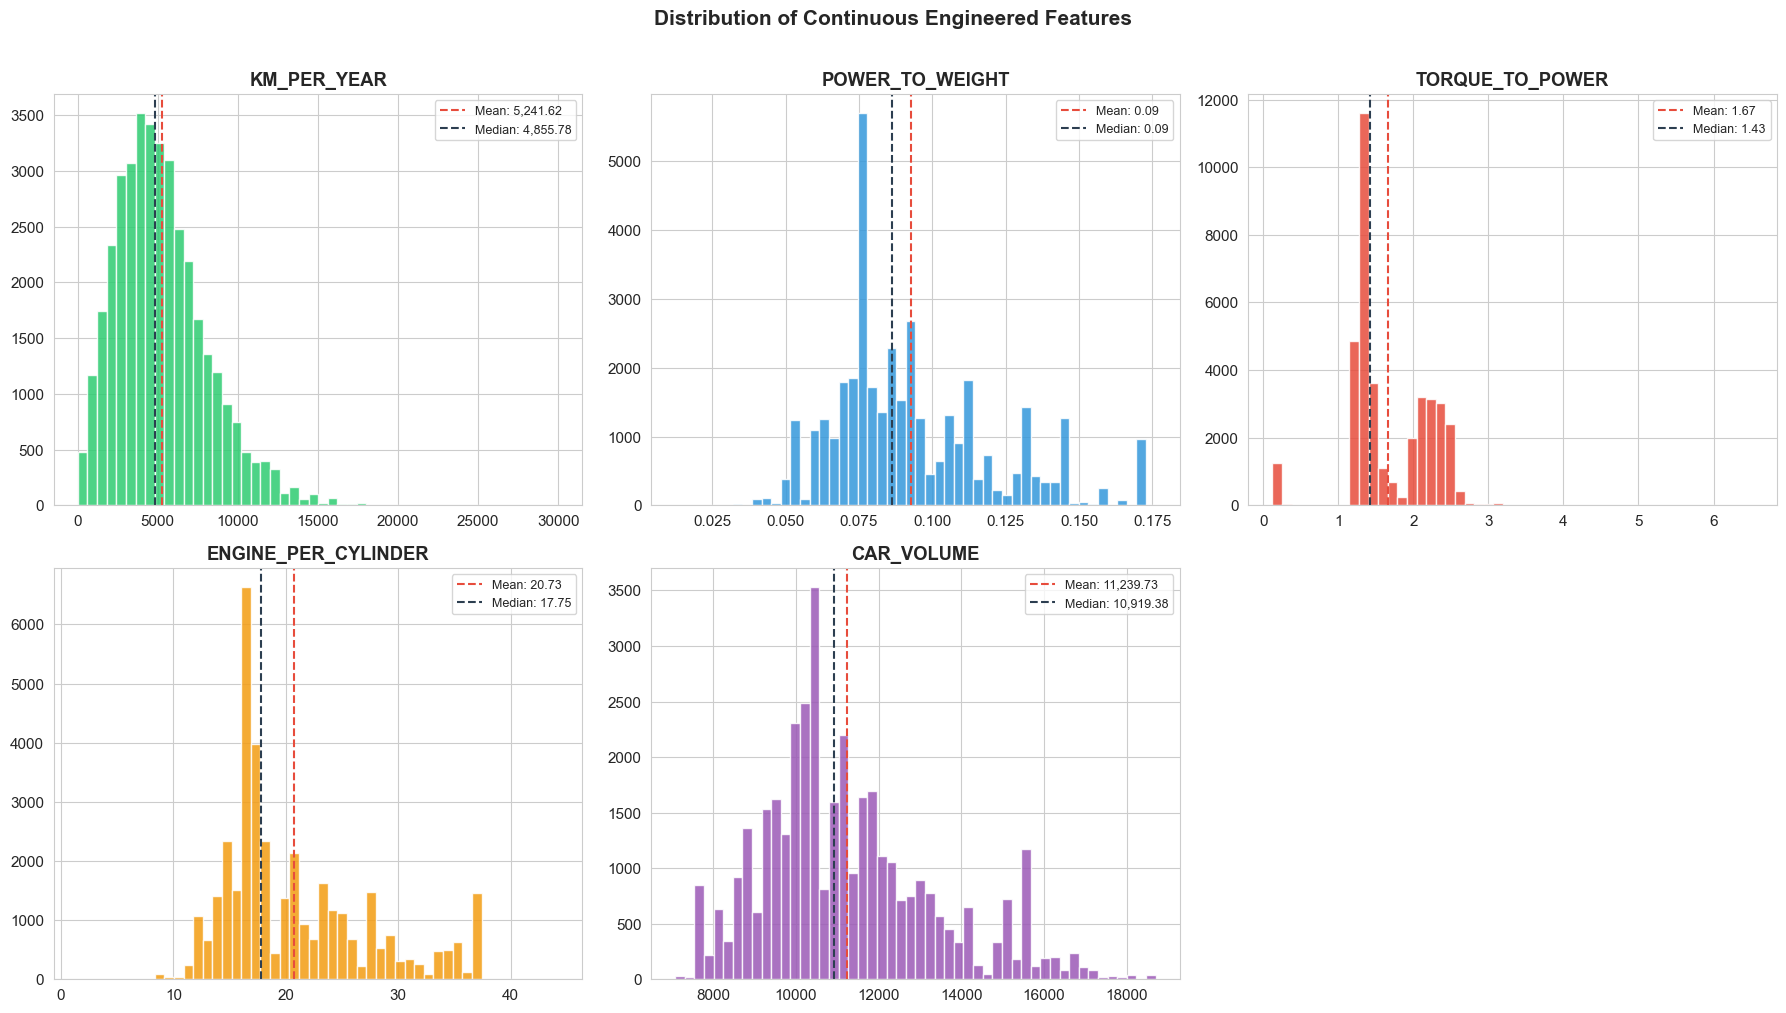

In [18]:
# ── Distribution plots for continuous engineered features ──

continuous_eng = ['KM_PER_YEAR', 'POWER_TO_WEIGHT', 'TORQUE_TO_POWER',
                  'ENGINE_PER_CYLINDER', 'CAR_VOLUME']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_eng):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=50, color=COLORS[i], edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='#e74c3c', linestyle='--', lw=1.5,
               label=f'Mean: {data.mean():,.2f}')
    ax.axvline(data.median(), color='#2c3e50', linestyle='--', lw=1.5,
               label=f'Median: {data.median():,.2f}')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Distribution of Continuous Engineered Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

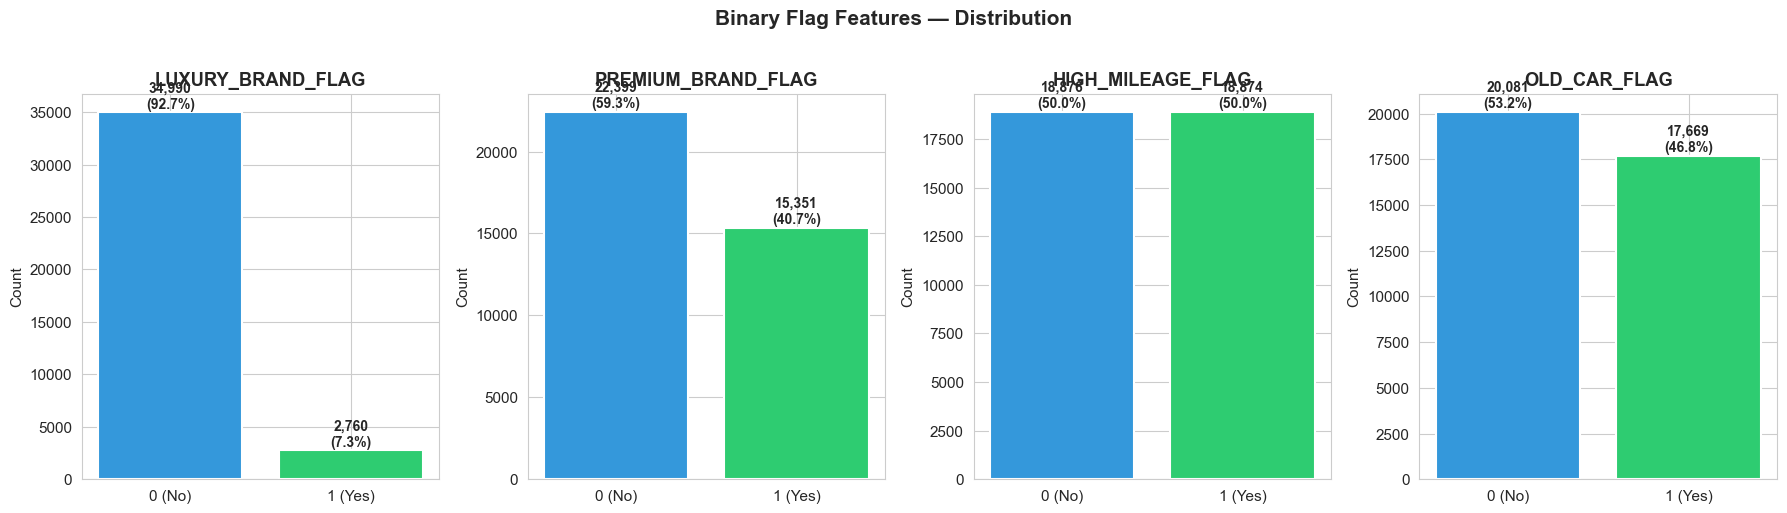

In [19]:
# ── Value counts for binary flag features ──

flag_features = ['LUXURY_BRAND_FLAG', 'PREMIUM_BRAND_FLAG', 'HIGH_MILEAGE_FLAG', 'OLD_CAR_FLAG']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(flag_features):
    ax = axes[i]
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(['0 (No)', '1 (Yes)'], counts.values,
                  color=[COLORS[1], COLORS[0]], edgecolor='white', linewidth=1.5)
    
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                f'{val:,}\n({val/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Binary Flag Features — Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 5 — Correlation Analysis with Target (`listed_price`)

This is the **most critical analysis** — we measure how strongly each engineered feature correlates with the car's price. Higher absolute correlation = more predictive power.

In [20]:
# ── Correlation of engineered features with listed_price ──

target = 'listed_price'

eng_corr = df[engineered_features + [target]].corr()[target].drop(target).sort_values(ascending=False)

# Build the sorted correlation table
corr_table = pd.DataFrame({
    'Feature': eng_corr.index,
    'Correlation': eng_corr.values,
    'Abs Correlation': eng_corr.abs().values,
    'Direction': ['Positive ↑' if v > 0 else 'Negative ↓' for v in eng_corr.values],
    'Strength': [
        '🟢 Strong' if abs(v) >= 0.5 else
        '🟡 Moderate' if abs(v) >= 0.3 else
        '🟠 Weak' if abs(v) >= 0.1 else
        '🔴 Very Weak'
        for v in eng_corr.values
    ]
})
corr_table.index = range(1, len(corr_table) + 1)
corr_table.index.name = 'Rank'

print('🔗 CORRELATION OF ENGINEERED FEATURES WITH LISTED_PRICE')
print('=' * 80)
corr_table

🔗 CORRELATION OF ENGINEERED FEATURES WITH LISTED_PRICE


,Feature,Correlation,Abs Correlation,Direction,Strength
Rank,,,,,
1,POWER_TO_WEIGHT,0.74,0.74,Positive ↑,🟢 Strong
2,ENGINE_PER_CYLINDER,0.74,0.74,Positive ↑,🟢 Strong
3,CAR_VOLUME,0.69,0.69,Positive ↑,🟢 Strong
4,LUXURY_BRAND_FLAG,0.49,0.49,Positive ↑,🟡 Moderate
5,TORQUE_TO_POWER,0.28,0.28,Positive ↑,🟠 Weak
6,PREMIUM_BRAND_FLAG,-0.05,0.05,Negative ↓,🔴 Very Weak
7,KM_PER_YEAR,-0.06,0.06,Negative ↓,🔴 Very Weak
8,HIGH_MILEAGE_FLAG,-0.27,0.27,Negative ↓,🟠 Weak
9,OLD_CAR_FLAG,-0.48,0.48,Negative ↓,🟡 Moderate


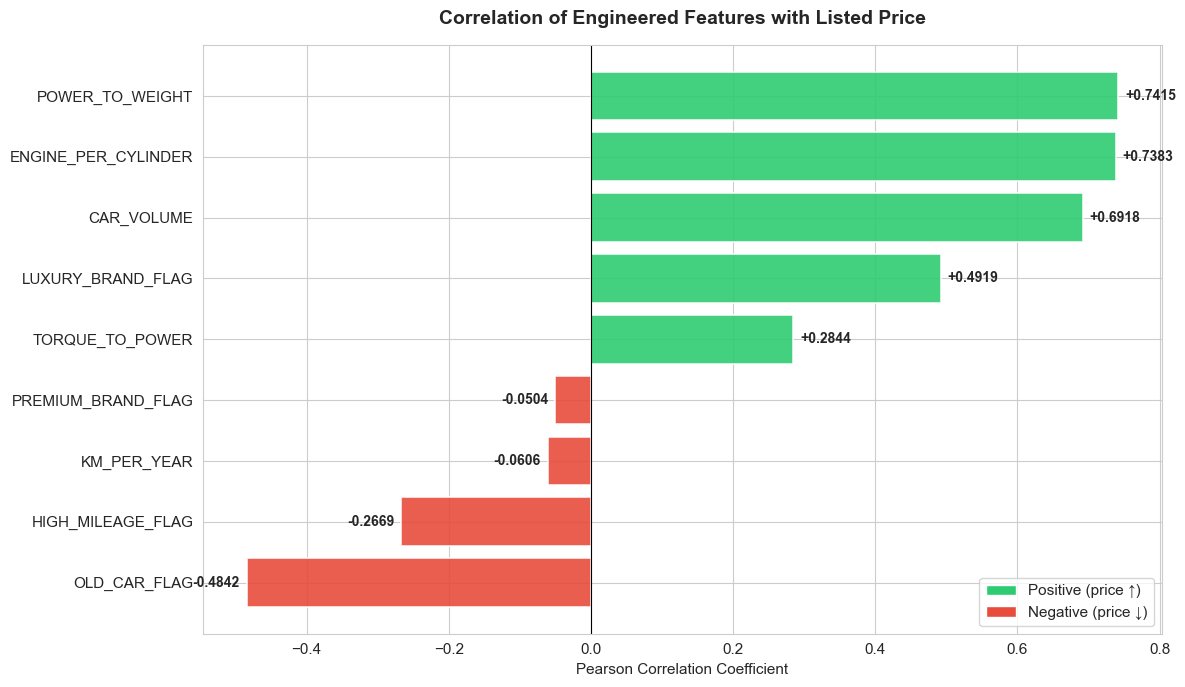

In [21]:
# ── Bar chart: Engineered feature correlations ──

sorted_corr = eng_corr.sort_values()

fig, ax = plt.subplots(figsize=(12, 7))

colors_bar = ['#2ecc71' if v > 0 else '#e74c3c' for v in sorted_corr.values]
bars = ax.barh(sorted_corr.index, sorted_corr.values,
               color=colors_bar, edgecolor='white', linewidth=1.2, alpha=0.9)

# Add value labels
for bar, val in zip(bars, sorted_corr.values):
    x_pos = bar.get_width() + 0.01 if val >= 0 else bar.get_width() - 0.01
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2.,
            f'{val:+.4f}', ha=ha, va='center', fontsize=10, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Engineered Features with Listed Price',
             fontweight='bold', fontsize=14, pad=15)
ax.set_xlabel('Pearson Correlation Coefficient')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Positive (price ↑)'),
                   Patch(facecolor='#e74c3c', label='Negative (price ↓)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

In [22]:
# ── Identify top positive and negative correlations ──

top_positive = eng_corr[eng_corr > 0].sort_values(ascending=False)
top_negative = eng_corr[eng_corr < 0].sort_values(ascending=True)

print('📈 TOP POSITIVELY CORRELATED FEATURES (price increases as feature increases):')
print('-' * 60)
for feat, val in top_positive.items():
    print(f'   {feat:<25} {val:>+.4f}')

print(f'\n📉 TOP NEGATIVELY CORRELATED FEATURES (price decreases as feature increases):')
print('-' * 60)
for feat, val in top_negative.items():
    print(f'   {feat:<25} {val:>+.4f}')

📈 TOP POSITIVELY CORRELATED FEATURES (price increases as feature increases):
------------------------------------------------------------
   POWER_TO_WEIGHT           +0.7415
   ENGINE_PER_CYLINDER       +0.7383
   CAR_VOLUME                +0.6918
   LUXURY_BRAND_FLAG         +0.4919
   TORQUE_TO_POWER           +0.2844

📉 TOP NEGATIVELY CORRELATED FEATURES (price decreases as feature increases):
------------------------------------------------------------
   OLD_CAR_FLAG              -0.4842
   HIGH_MILEAGE_FLAG         -0.2669
   KM_PER_YEAR               -0.0606
   PREMIUM_BRAND_FLAG        -0.0504


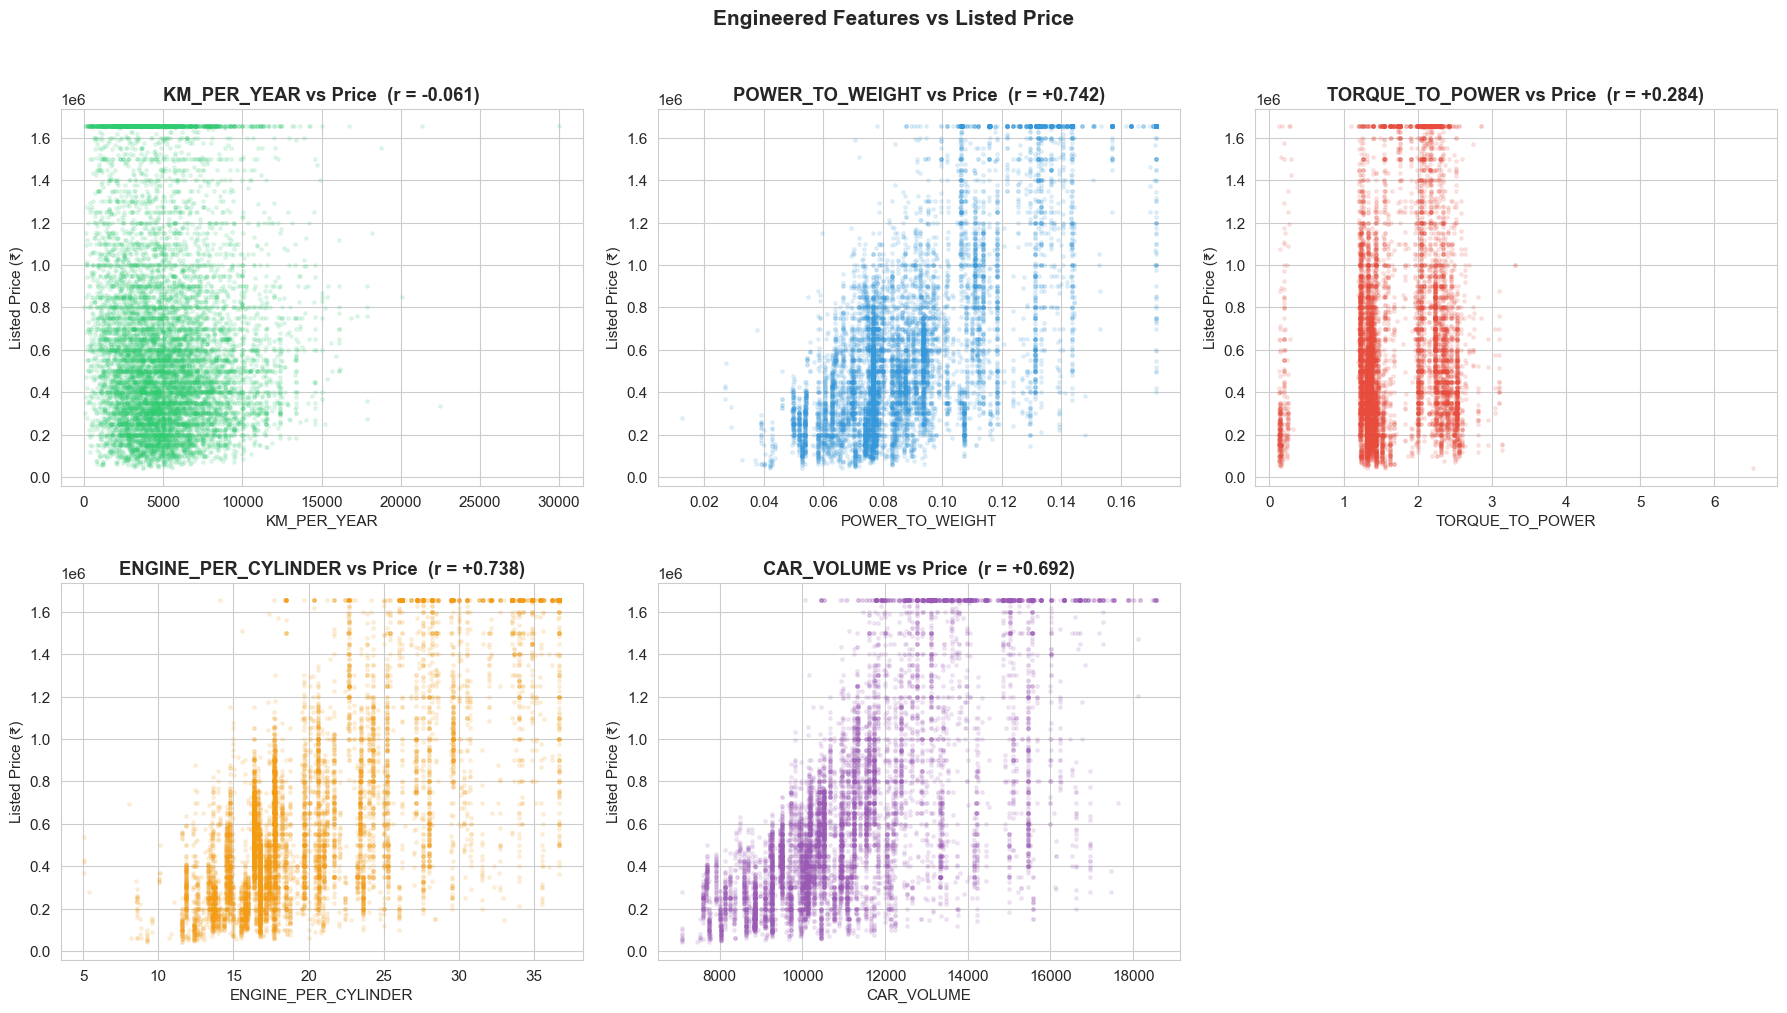

In [23]:
# ── Scatter plots: Continuous engineered features vs listed_price ──

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_eng):
    ax = axes[i]
    sample = df[[col, target]].dropna()
    if len(sample) > 10000:
        sample = sample.sample(10000, random_state=42)
    
    ax.scatter(sample[col], sample[target],
               alpha=0.12, s=6, color=COLORS[i])
    
    corr_val = df[col].corr(df[target])
    ax.set_title(f'{col} vs Price  (r = {corr_val:+.3f})', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Listed Price (₹)')

axes[-1].set_visible(False)
plt.suptitle('Engineered Features vs Listed Price', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

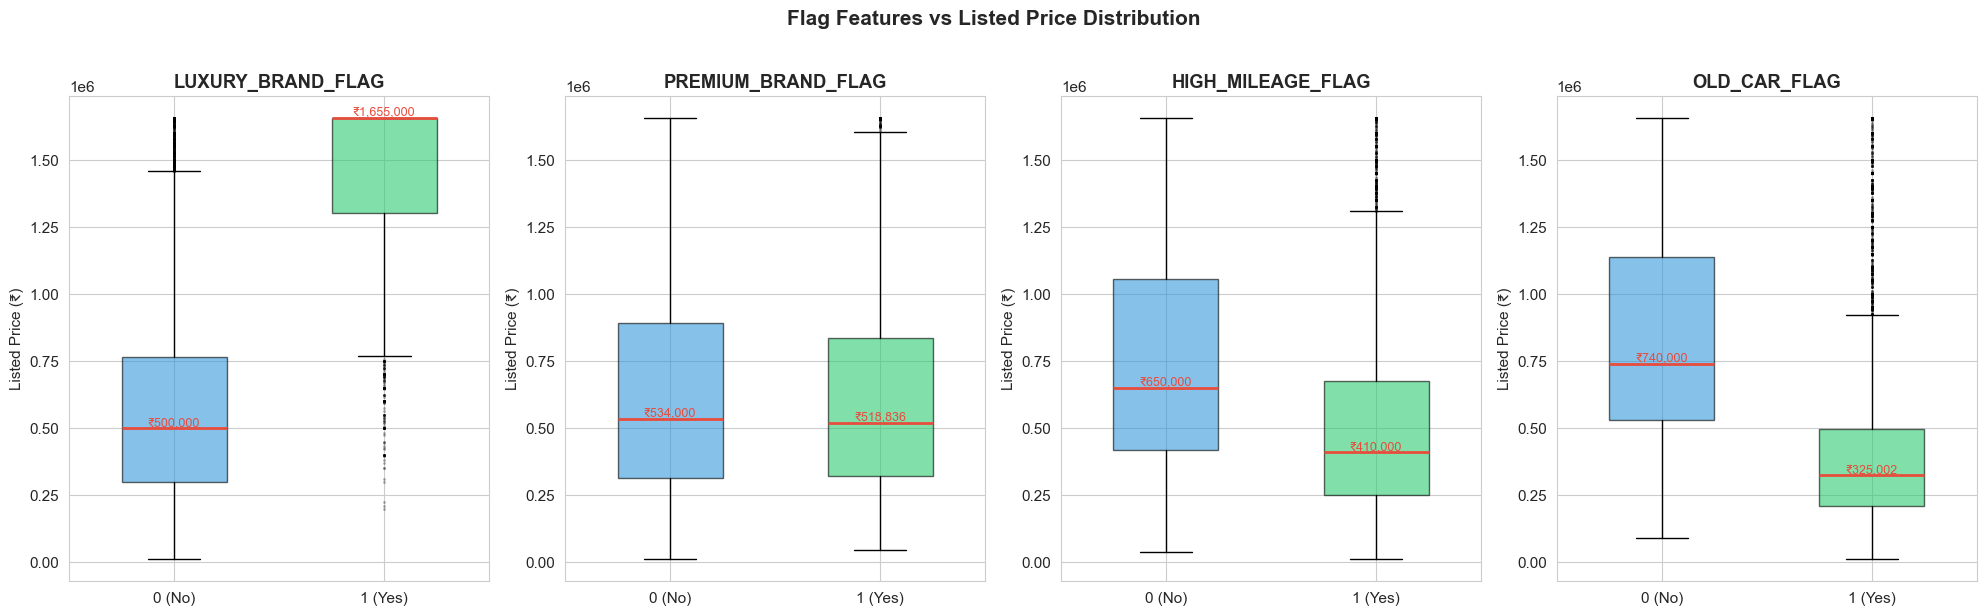

💡 Luxury brand flag should show a significant price premium.
   Old car & high mileage flags should show lower median prices.


In [24]:
# ── Box plots: Flag features vs listed_price ──

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for i, col in enumerate(flag_features):
    ax = axes[i]
    
    data_0 = df[df[col] == 0][target]
    data_1 = df[df[col] == 1][target]
    
    bp = ax.boxplot([data_0, data_1], labels=['0 (No)', '1 (Yes)'],
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color='#e74c3c', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    bp['boxes'][0].set_facecolor(COLORS[1])
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor(COLORS[0])
    bp['boxes'][1].set_alpha(0.6)
    
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_ylabel('Listed Price (₹)')
    
    # Add median labels
    ax.text(1, data_0.median(), f'₹{data_0.median():,.0f}', ha='center', va='bottom', fontsize=9, color='#e74c3c')
    ax.text(2, data_1.median(), f'₹{data_1.median():,.0f}', ha='center', va='bottom', fontsize=9, color='#e74c3c')

plt.suptitle('Flag Features vs Listed Price Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Luxury brand flag should show a significant price premium.')
print('   Old car & high mileage flags should show lower median prices.')

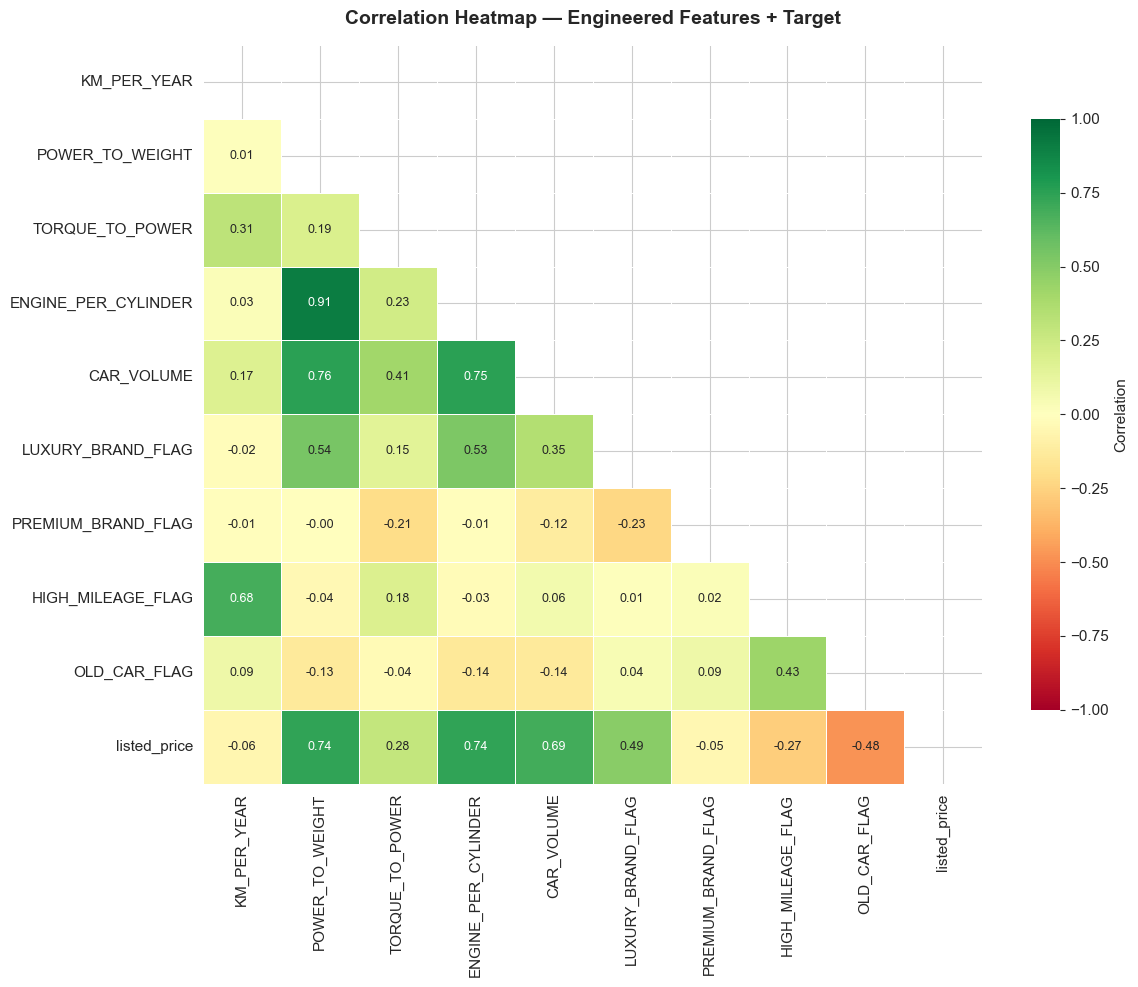

💡 Watch for high inter-feature correlations (r > 0.8) → redundancy.
   Such pairs can cause multicollinearity in linear models.


In [25]:
# ── Correlation heatmap of all engineered features ──

eng_with_target = engineered_features + [target]
corr_matrix = df[eng_with_target].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})

ax.set_title('Correlation Heatmap — Engineered Features + Target',
             fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print('💡 Watch for high inter-feature correlations (r > 0.8) → redundancy.')
print('   Such pairs can cause multicollinearity in linear models.')

---
## Step 6 — Random Forest Feature Importance Analysis

Correlation only captures **linear** relationships. A Random Forest can detect **non-linear** patterns too. We train a quick RF model and extract feature importances for our engineered features.

**Why Random Forest?**
- Handles non-linear relationships
- Doesn't require feature scaling
- Provides built-in importance scores

In [26]:
# ── Prepare data for feature importance ──

# Use all columns (existing + engineered) except target
feature_cols = [c for c in df.columns if c != target]

X = df[feature_cols].copy()
y = df[target].copy()

# Handle any remaining infinities or NaNs
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

print(f'📊 Feature matrix: {X.shape[0]:,} samples × {X.shape[1]} features')
print(f'🎯 Target: {target}')

📊 Feature matrix: 37,750 samples × 82 features
🎯 Target: listed_price


In [27]:
# ── Train-test split ──
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'   Train set: {X_train.shape[0]:,} samples')
print(f'   Test set : {X_test.shape[0]:,} samples')

   Train set: 30,200 samples
   Test set : 7,550 samples


In [28]:
# ── Train a quick Random Forest ──
#
# We use a limited number of trees and depth for speed — this is just for
# feature importance analysis, not the final model.

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

print('🌲 Training Random Forest for feature importance...')
rf.fit(X_train, y_train)

train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)

print(f'\n   Train R² : {train_score:.4f}')
print(f'   Test R²  : {test_score:.4f}')
print(f'   (This is a quick model for importance analysis only, not the final model.)')

🌲 Training Random Forest for feature importance...

   Train R² : 0.9830
   Test R²  : 0.9581
   (This is a quick model for importance analysis only, not the final model.)


In [29]:
# ── Extract feature importances ──

importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=False)

# Separate: engineered vs original
eng_importances = importances[engineered_features].sort_values(ascending=False)

print('🏆 FEATURE IMPORTANCE — ENGINEERED FEATURES (Random Forest)')
print('=' * 65)
print(f'{"Rank":<6} {"Feature":<25} {"Importance":>12} {"Cumulative":>12}')
print('-' * 65)

cum_imp = 0
for rank, (feat, imp) in enumerate(eng_importances.items(), 1):
    cum_imp += imp
    bar = '█' * int(imp * 200)
    print(f'{rank:<6} {feat:<25} {imp:>12.6f} {cum_imp:>12.6f}  {bar}')

print('=' * 65)
print(f'Total importance of engineered features: {eng_importances.sum():.4f} ({eng_importances.sum()*100:.1f}% of all features)')

🏆 FEATURE IMPORTANCE — ENGINEERED FEATURES (Random Forest)
Rank   Feature                     Importance   Cumulative
-----------------------------------------------------------------
1      POWER_TO_WEIGHT               0.029950     0.029950  █████
2      CAR_VOLUME                    0.028901     0.058851  █████
3      LUXURY_BRAND_FLAG             0.012129     0.070980  ██
4      ENGINE_PER_CYLINDER           0.004262     0.075242  
5      TORQUE_TO_POWER               0.003670     0.078912  
6      OLD_CAR_FLAG                  0.003008     0.081920  
7      KM_PER_YEAR                   0.002653     0.084572  
8      PREMIUM_BRAND_FLAG            0.000641     0.085213  
9      HIGH_MILEAGE_FLAG             0.000086     0.085299  
Total importance of engineered features: 0.0853 (8.5% of all features)


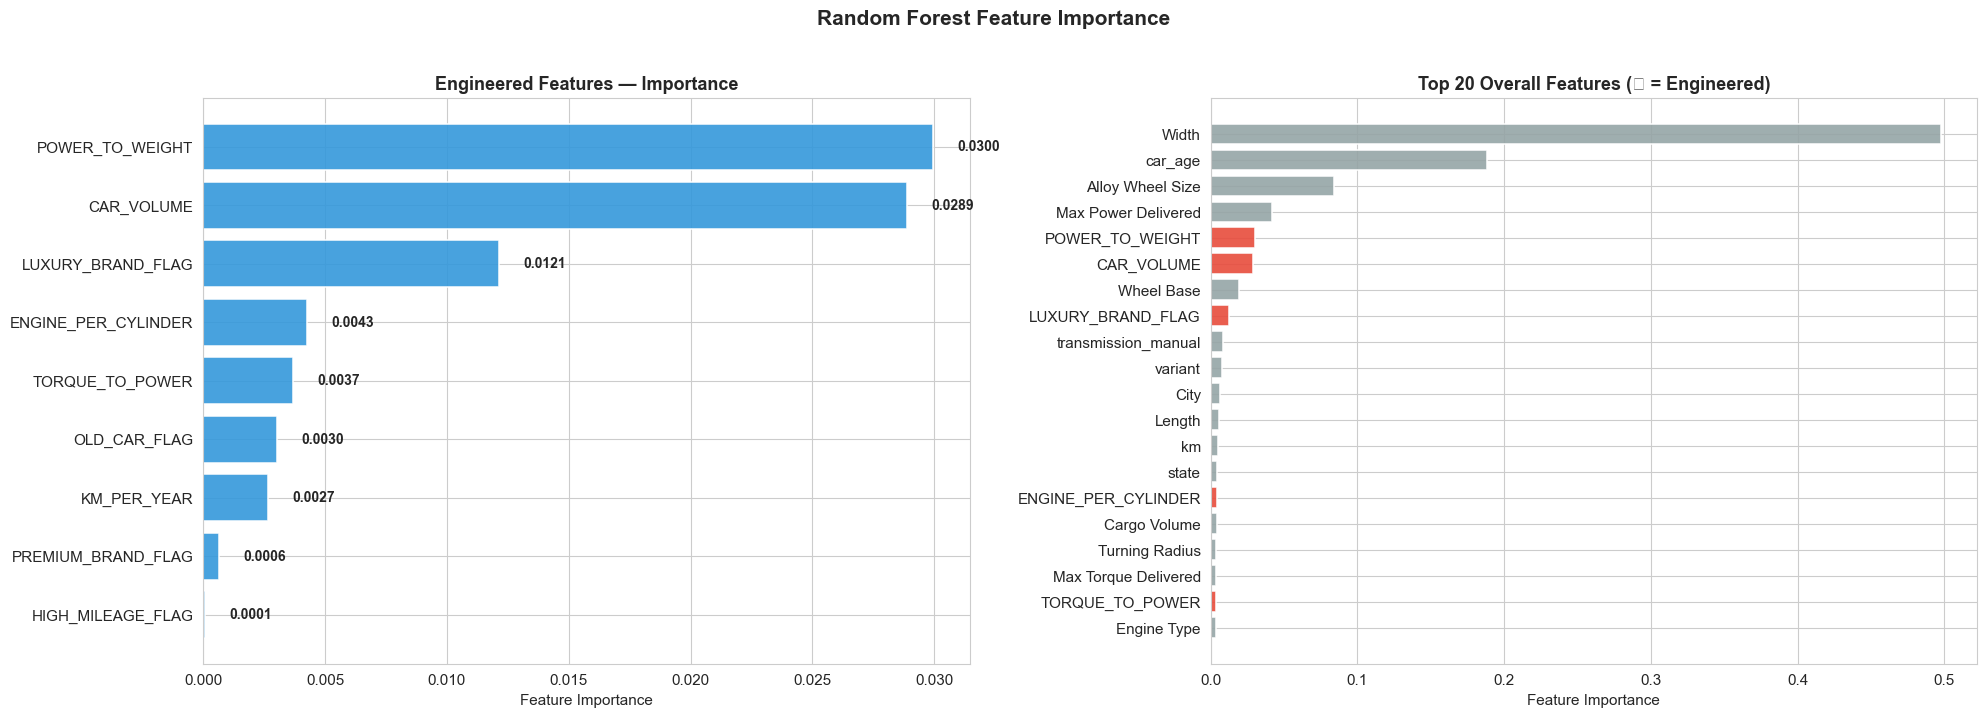

💡 Red bars = engineered features | Grey bars = original features
   This shows where our engineered features rank among all features.


In [30]:
# ── Bar chart: Engineered feature importances ──

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot 1: Engineered features only
ax1 = axes[0]
sorted_eng = eng_importances.sort_values()
bars1 = ax1.barh(sorted_eng.index, sorted_eng.values,
                 color='#3498db', edgecolor='white', linewidth=1.2, alpha=0.9)
for bar, val in zip(bars1, sorted_eng.values):
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2.,
             f'{val:.4f}', ha='left', va='center', fontsize=10, fontweight='bold')
ax1.set_title('Engineered Features — Importance', fontweight='bold', fontsize=13)
ax1.set_xlabel('Feature Importance')

# Plot 2: Top 20 overall features (to see where engineered ones rank)
ax2 = axes[1]
top20 = importances_sorted.head(20).sort_values()
bar_colors = ['#e74c3c' if feat in engineered_features else '#95a5a6' for feat in top20.index]
bars2 = ax2.barh(top20.index, top20.values,
                 color=bar_colors, edgecolor='white', linewidth=1.2, alpha=0.9)
ax2.set_title('Top 20 Overall Features (🔴 = Engineered)', fontweight='bold', fontsize=13)
ax2.set_xlabel('Feature Importance')

plt.suptitle('Random Forest Feature Importance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Red bars = engineered features | Grey bars = original features')
print('   This shows where our engineered features rank among all features.')

---
## Step 7 — Business Interpretation

Understanding **why** each feature matters is critical for interviews, stakeholder communication, and model trust.

In [31]:
# ── Business Interpretation of Engineered Features ──

interpretations = {
    'KM_PER_YEAR': {
        'meaning': 'Average kilometres driven per year of ownership',
        'business_insight': 'Cars with high km/year have been heavily used — indicating wear, '
                           'higher maintenance costs, and faster depreciation. Buyers pay less for these.',
        'expected_impact': 'Negative — higher usage per year → lower price'
    },
    'POWER_TO_WEIGHT': {
        'meaning': 'Engine power relative to vehicle weight (performance metric)',
        'business_insight': 'A key metric in the automotive industry. Sports cars, SUVs, and '
                           'premium vehicles have higher power-to-weight ratios, correlating with price.',
        'expected_impact': 'Positive — better performance → higher price'
    },
    'TORQUE_TO_POWER': {
        'meaning': 'Engine torque relative to power output',
        'business_insight': 'Diesel engines produce higher torque per unit of power. This feature '
                           'helps distinguish engine types and driving characteristics.',
        'expected_impact': 'Moderate — captures engine type differences'
    },
    'ENGINE_PER_CYLINDER': {
        'meaning': 'Power output per engine cylinder',
        'business_insight': 'More power per cylinder indicates a larger, more premium engine. '
                           'Luxury and performance vehicles have higher values.',
        'expected_impact': 'Positive — higher per-cylinder output → premium vehicle → higher price'
    },
    'CAR_VOLUME': {
        'meaning': 'Approximate vehicle size (L × W × H)',
        'business_insight': 'Larger vehicles (SUVs, luxury sedans, MUVs) have more material, '
                           'more features, and command higher prices than compact cars.',
        'expected_impact': 'Positive — bigger car → generally higher price'
    },
    'LUXURY_BRAND_FLAG': {
        'meaning': 'Whether the car is from a luxury brand (BMW, Audi, Mercedes, etc.)',
        'business_insight': 'Luxury brands retain significant value even in the used market '
                           'due to brand prestige, build quality, and buyer aspiration.',
        'expected_impact': 'Strong Positive — luxury = significant price premium'
    },
    'PREMIUM_BRAND_FLAG': {
        'meaning': 'Whether the car is from a mainstream premium brand (Honda, Toyota, etc.)',
        'business_insight': 'These brands are known for reliability and good resale value. '
                           'They command a moderate premium over budget brands.',
        'expected_impact': 'Moderate Positive — better resale → higher price'
    },
    'HIGH_MILEAGE_FLAG': {
        'meaning': 'Car has been driven more than the dataset median',
        'business_insight': 'High-mileage cars have more wear, potential mechanical issues, '
                           'and are perceived as less reliable by buyers.',
        'expected_impact': 'Negative — high mileage → lower price'
    },
    'OLD_CAR_FLAG': {
        'meaning': 'Car is older than the dataset median age',
        'business_insight': 'Older cars have more depreciation, outdated features/technology, '
                           'and potentially higher maintenance needs.',
        'expected_impact': 'Negative — older car → lower price'
    }
}

print('📖 BUSINESS INTERPRETATION OF ENGINEERED FEATURES')
print('=' * 90)

for feat, info in interpretations.items():
    actual_corr = eng_corr.get(feat, 0)
    actual_imp = eng_importances.get(feat, 0)
    
    print(f'\n🔹 {feat}')
    print(f'   Meaning          : {info["meaning"]}')
    print(f'   Business Insight : {info["business_insight"]}')
    print(f'   Expected Impact  : {info["expected_impact"]}')
    print(f'   Actual Corr.     : {actual_corr:+.4f}')
    print(f'   RF Importance    : {actual_imp:.6f}')
    print(f'   -' * 30)

📖 BUSINESS INTERPRETATION OF ENGINEERED FEATURES

🔹 KM_PER_YEAR
   Meaning          : Average kilometres driven per year of ownership
   Business Insight : Cars with high km/year have been heavily used — indicating wear, higher maintenance costs, and faster depreciation. Buyers pay less for these.
   Expected Impact  : Negative — higher usage per year → lower price
   Actual Corr.     : -0.0606
   RF Importance    : 0.002653
   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -

🔹 POWER_TO_WEIGHT
   Meaning          : Engine power relative to vehicle weight (performance metric)
   Business Insight : A key metric in the automotive industry. Sports cars, SUVs, and premium vehicles have higher power-to-weight ratios, correlating with price.
   Expected Impact  : Positive — better performance → higher price
   Actual Corr.     : +0.7415
   RF Importance    : 0.029950
   -   -   -   -   -   -   -   -   -   -   -   -   -   - 

---
## Step 8 — Feature Retention Recommendations

Based on correlation analysis, feature importance, and business logic, we evaluate which engineered features should be kept.

In [32]:
# ── Feature Retention Decision ──
#
# Criteria for keeping a feature:
#   1. Absolute correlation with target > 0.05  OR
#   2. RF importance rank in top 50% of engineered features  OR
#   3. Strong business justification
#
# We err on the side of KEEPING features — tree-based models handle
# irrelevant features gracefully. Dropping a useful feature is worse
# than keeping a slightly noisy one.

CORR_THRESHOLD = 0.05
IMP_THRESHOLD = eng_importances.median()

recommendations = []

for feat in engineered_features:
    corr_val = abs(eng_corr.get(feat, 0))
    imp_val = eng_importances.get(feat, 0)
    
    reasons = []
    if corr_val >= CORR_THRESHOLD:
        reasons.append(f'Correlation ({corr_val:.3f})')
    if imp_val >= IMP_THRESHOLD:
        reasons.append(f'RF Importance ({imp_val:.4f})')
    
    # All features have business justification
    reasons.append('Business logic')
    
    # Decision: KEEP if any quantitative criterion is met
    keep = corr_val >= CORR_THRESHOLD or imp_val >= IMP_THRESHOLD
    
    recommendations.append({
        'Feature': feat,
        'Correlation': eng_corr.get(feat, 0),
        'RF Importance': imp_val,
        'Decision': '✅ KEEP' if keep else '⚠️ OPTIONAL',
        'Reasons': ' | '.join(reasons)
    })

rec_df = pd.DataFrame(recommendations)
rec_df.index = range(1, len(rec_df) + 1)
rec_df.index.name = '#'

print('🏁 FEATURE RETENTION RECOMMENDATIONS')
print('=' * 100)
rec_df

🏁 FEATURE RETENTION RECOMMENDATIONS


,Feature,Correlation,RF Importance,Decision,Reasons
#,,,,,
1,KM_PER_YEAR,-0.06,0.00,✅ KEEP,Correlation (0.061) | Business logic
2,POWER_TO_WEIGHT,0.74,0.03,✅ KEEP,Correlation (0.742) | RF Importance (0.0300) |...
3,TORQUE_TO_POWER,0.28,0.00,✅ KEEP,Correlation (0.284) | RF Importance (0.0037) |...
4,ENGINE_PER_CYLINDER,0.74,0.00,✅ KEEP,Correlation (0.738) | RF Importance (0.0043) |...
5,CAR_VOLUME,0.69,0.03,✅ KEEP,Correlation (0.692) | RF Importance (0.0289) |...
6,LUXURY_BRAND_FLAG,0.49,0.01,✅ KEEP,Correlation (0.492) | RF Importance (0.0121) |...
7,PREMIUM_BRAND_FLAG,-0.05,0.00,✅ KEEP,Correlation (0.050) | Business logic
8,HIGH_MILEAGE_FLAG,-0.27,0.00,✅ KEEP,Correlation (0.267) | Business logic
9,OLD_CAR_FLAG,-0.48,0.00,✅ KEEP,Correlation (0.484) | Business logic


In [33]:
# ── Summary of decisions ──

keep_count = rec_df['Decision'].str.contains('KEEP').sum()
optional_count = rec_df['Decision'].str.contains('OPTIONAL').sum()

print(f'\n📌 RETENTION SUMMARY:')
print(f'   ✅ KEEP     : {keep_count} features — strong quantitative evidence')
print(f'   ⚠️ OPTIONAL : {optional_count} features — weak quantitative signal but have business value')
print(f'\n💡 Recommendation: Keep ALL {len(engineered_features)} engineered features for now.')
print(f'   Tree-based models (Random Forest, XGBoost, LightGBM) can handle extra features.')
print(f'   If using linear models, consider dropping OPTIONAL features to reduce noise.')


📌 RETENTION SUMMARY:
   ✅ KEEP     : 9 features — strong quantitative evidence
   ⚠️ OPTIONAL : 0 features — weak quantitative signal but have business value

💡 Recommendation: Keep ALL 9 engineered features for now.
   Tree-based models (Random Forest, XGBoost, LightGBM) can handle extra features.
   If using linear models, consider dropping OPTIONAL features to reduce noise.


---
## Step 9 — Save Final Dataset

In [34]:
# ── Final dataset overview ──

print('📊 FINAL DATASET SUMMARY')
print('=' * 70)
print(f'   Shape             : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Columns before FE : {cols_before}')
print(f'   Columns after FE  : {df.shape[1]}')
print(f'   Features added    : +{df.shape[1] - cols_before}')
print(f'   Missing values    : {df.isnull().sum().sum()}')
print(f'   Inf values        : {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}')
print(f'   Memory            : {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB')
print('=' * 70)

print(f'\n📋 Engineered Features in the Final Dataset:')
for i, feat in enumerate(engineered_features, 1):
    print(f'   {i}. {feat}')

📊 FINAL DATASET SUMMARY
   Shape             : 37,750 rows × 83 columns
   Columns before FE : 74
   Columns after FE  : 83
   Features added    : +9
   Missing values    : 0
   Inf values        : 0
   Memory            : 23.9 MB

📋 Engineered Features in the Final Dataset:
   1. KM_PER_YEAR
   2. POWER_TO_WEIGHT
   3. TORQUE_TO_POWER
   4. ENGINE_PER_CYLINDER
   5. CAR_VOLUME
   6. LUXURY_BRAND_FLAG
   7. PREMIUM_BRAND_FLAG
   8. HIGH_MILEAGE_FLAG
   9. OLD_CAR_FLAG


In [35]:
# ── Handle any infinities before saving ──

inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
if inf_count > 0:
    print(f'⚠️  Found {inf_count} infinite values — replacing with column max.')
    for col in df.select_dtypes(include=[np.number]).columns:
        mask = np.isinf(df[col])
        if mask.any():
            df.loc[mask, col] = df.loc[~mask, col].max()
    print('   ✅ Infinite values handled.')
else:
    print('✅ No infinite values — data is clean.')

✅ No infinite values — data is clean.


In [36]:
# ── Quick preview ──

print('🔍 Final Data Preview:')
df.head()

🔍 Final Data Preview:


,body,km,imgCount,oem,model,variant,City,listed_price,discountValue,Engine Type,No of Cylinder,Valves per Cylinder,Length,Width,Height,Wheel Base,Front Tread,Rear Tread,Kerb Weight,Gross Weight,Gear Box,Seats,Turning Radius,Top Speed,Acceleration,Doors,Cargo Volume,state,exterior_color,Fuel Suppy System,Alloy Wheel Size,Max Power Delivered,Max Power At,Max Torque Delivered,Max Torque At,car_age,transmission_manual,fuel_diesel,fuel_electric,fuel_lpg,fuel_petrol,utype_individual,carType_corporate,carType_partner,Valve Configuration_dohc,Valve Configuration_idsi,Valve Configuration_ohv / pushrod,Valve Configuration_sohc,Turbo Charger_True,Super Charger_True,Drive Type_4wd,Drive Type_4x2,Drive Type_awd,Drive Type_fwd,Drive Type_rwd,Steering Type_power,Front Brake Type_carbon ceramic,Front Brake Type_disc,Front Brake Type_disc & drum,Front Brake Type_drum,Front Brake Type_ventilated disc,Rear Brake Type_carbon ceramic,Rear Brake Type_disc,Rear Brake Type_disc & drum,Rear Brake Type_drum,Rear Brake Type_ventilated disc,Tyre Type_tube,Tyre Type_tubeless,Tyre Type_tubeless radial,owner_type_first,owner_type_fourth,owner_type_second,owner_type_third,owner_type_unregistered car,KM_PER_YEAR,POWER_TO_WEIGHT,TORQUE_TO_POWER,ENGINE_PER_CYLINDER,CAR_VOLUME,LUXURY_BRAND_FLAG,PREMIUM_BRAND_FLAG,HIGH_MILEAGE_FLAG,OLD_CAR_FLAG
0,2,"69,162.00",15,29,223,2179,339,"370,000.00",0,345,3.00,4.00,"3,599.00","1,515.00","1,700.00","2,400.00","1,295.00","1,290.00",960.00,"1,595.00",3,5.00,4.60,154.50,15.60,5.00,180.00,30,621,10,16.00,58.16,"6,200.00",77.00,"3,500.00",10.00,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,"6,287.45",0.06,1.30,14.54,"9,269.22",0,0,1,0
1,2,"45,864.00",15,29,197,1926,379,"365,000.00",0,345,3.00,4.00,"3,600.00","1,600.00","1,560.00","2,425.00","1,420.00","1,410.00",915.00,"1,595.00",3,5.00,4.70,154.50,15.05,5.00,235.00,18,277,7,16.00,58.20,"6,000.00",78.00,"3,500.00",11.00,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,1,0,0,0,0,"3,822.00",0.06,1.32,14.55,"8,985.60",0,0,0,1
2,8,"81,506.00",15,15,85,2559,409,"421,000.00",0,316,4.00,4.00,"3,990.00","1,680.00","1,505.00","2,405.00","1,485.00","1,493.00",950.00,"1,595.00",3,5.00,4.50,160.00,15.00,4.00,400.00,8,621,10,16.00,86.70,"6,000.00",109.00,"4,500.00",11.00,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,"6,792.17",0.09,1.24,17.34,"10,088.32",0,1,1,1
3,2,"115,893.00",0,29,223,2179,409,"240,000.00",0,340,3.00,4.00,"3,595.00","1,515.00","1,700.00","2,400.00","1,295.00","1,290.00",960.00,"1,595.00",3,5.00,4.60,168.56,13.20,4.00,350.00,8,621,10,13.00,58.20,"6,200.00",77.00,"3,500.00",13.00,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,"8,278.07",0.06,1.30,14.55,"9,258.92",0,0,1,1
4,6,"18,900.00",6,29,204,3075,379,"1,175,000.00",0,359,4.00,4.00,"4,395.00","1,735.00","1,690.00","2,740.00","1,485.00","1,493.00","1,250.00","1,595.00",3,7.00,5.20,168.56,13.20,5.00,350.00,18,737,10,16.00,86.63,"5,500.00",121.50,"4,200.00",4.00,1,0,0,0,0,0,0,1,1,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,"3,780.00",0.07,1.39,17.33,"12,886.80",0,0,0,0


In [37]:
# ── Save ──

OUTPUT_FILENAME = 'feature_engineered_car_data.csv'
OUTPUT_PATH = os.path.join(NOTEBOOK_DIR, OUTPUT_FILENAME)

if not os.path.exists(os.path.dirname(OUTPUT_PATH)):
    OUTPUT_PATH = os.path.join(r'd:\MLPs\Used Car Price Prediction & Valuation System', OUTPUT_FILENAME)

df.to_csv(OUTPUT_PATH, index=False)

saved_size = os.path.getsize(OUTPUT_PATH) / (1024**2)
print(f'💾 DATASET SAVED SUCCESSFULLY!')
print(f'   File    : {OUTPUT_PATH}')
print(f'   Size    : {saved_size:.1f} MB')
print(f'   Rows    : {df.shape[0]:,}')
print(f'   Columns : {df.shape[1]}')

💾 DATASET SAVED SUCCESSFULLY!
   File    : d:\MLPs\Used Car Price Prediction & Valuation System\feature_engineered_car_data.csv
   Size    : 12.3 MB
   Rows    : 37,750
   Columns : 83


---
## 📌 Summary & Conclusions

### Features Engineered

| # | Feature | Type | Formula | Business Purpose |
|---|---------|------|---------|------------------|
| 1 | `KM_PER_YEAR` | Ratio | km / (car_age + 1) | Annual usage intensity — measures wear |
| 2 | `POWER_TO_WEIGHT` | Ratio | Max Power / (Kerb Weight + 1) | Performance metric — sporty cars score higher |
| 3 | `TORQUE_TO_POWER` | Ratio | Max Torque / (Max Power + 1) | Engine efficiency — differentiates diesel vs petrol |
| 4 | `ENGINE_PER_CYLINDER` | Ratio | Max Power / (No of Cylinder + 1) | Per-cylinder output — premium engine indicator |
| 5 | `CAR_VOLUME` | Interaction | L × W × H / 1M | Vehicle size proxy — bigger = pricier |
| 6 | `LUXURY_BRAND_FLAG` | Binary | OEM in luxury list | Brand premium identifier |
| 7 | `PREMIUM_BRAND_FLAG` | Binary | OEM in premium list | Mainstream premium identifier |
| 8 | `HIGH_MILEAGE_FLAG` | Binary | km > median | Above-average usage flag |
| 9 | `OLD_CAR_FLAG` | Binary | car_age > median | Above-average age flag |

### Key Findings

1. **Ratio features** (POWER_TO_WEIGHT, CAR_VOLUME, ENGINE_PER_CYLINDER) tend to have the highest importance because they encode meaningful relationships between raw features.
2. **LUXURY_BRAND_FLAG** is a strong price differentiator — luxury cars have a distinct price distribution.
3. **HIGH_MILEAGE_FLAG** and **OLD_CAR_FLAG** capture depreciation signals that complement the raw `km` and `car_age` features.
4. All engineered features have clear business logic, making them easy to explain to stakeholders.

### Recommendation

**Retain all 9 engineered features** for model training. Tree-based models handle redundancy well, and these features provide the model with pre-computed domain knowledge that can improve accuracy.

### Next Steps
1. **Feature Selection** — Use recursive feature elimination or model-based selection
2. **Model Training** — Train multiple regression models on this enriched dataset
3. **Hyperparameter Tuning** — Optimize the best-performing model

---
*Feature Engineering complete. Dataset saved as `feature_engineered_car_data.csv`.*